In [ ]:
#Optimising a four-variable black-box function that represents the yield of a chemical process
#in a factory. The function is typically unimodal, with a single peak where yield is maximised. 



In [7]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from scipy.interpolate import griddata

# Your 4D spatial coordinate data (10 positions)
inputs = np.load('/home/mcevoyj777/_CAPSTONE/FUNC5/initial_inputs.npy')

# Your ouput values
output = np.load('/home/mcevoyj777/_CAPSTONE/FUNC5/initial_outputs.npy')
print(output.max())
extra_inputs = [[0.368468, 0.841273, 0.996733, 0.987257],[0.467189, 0.838051, 0.999999, 0.999999],
                [0.476092, 0.995411, 1.000000, 1.000000],[0.545208, 1.000000, 1.000000, 1.000000],
               [0.791104, 1.000000, 1.000000, 1.000000],[1.000000, 1.000000, 1.000000, 1.000000],
               [1.000000, 1.000000, 1.000000, 1.000000],[1.000000, 1.000000, 0.500000, 1.000000]]
extra_output = [2757.068210155631,2998.5110568875957,4572.46065867457,
                4774.9125949709805,5954.739063293253,8662.4825,8662.4825,
               4678.3425]

inputs = np.vstack([inputs, extra_inputs])
output = np.append(output, extra_output)
print(output.max())
print(inputs)
print(output)

# 2. Combine into a single Pandas DataFrame
df = pd.DataFrame(inputs, columns=['Input_W','Input_X', 'Input_Y', 'Input_Z'])
df['Output_Target'] = output

# 3. Compute the correlation matrix
# Change method to 'spearman' if relationships are non-linear curves
corr_matrix = df.corr(method='pearson')

# 4. Isolate how each input correlates *only* with the target output
target_corr = corr_matrix['Output_Target'].drop('Output_Target')

print("Correlation with Output:")
print(target_corr)

# Calculate non-linear relationship dependency (higher score = stronger relationship)
mi_scores = mutual_info_regression(inputs, output)

for name, score in zip(['Input_W','Input_X', 'Input_Y', 'Input_Z'], mi_scores):
    print(f"{name} Mutual Information Score: {score:.4f}")

# Fit a quick non-linear model that checks all 4 dimensions simultaneously
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(inputs, output)

# Extract total feature importances (including interactions)
importances = model.feature_importances_

for name, score in zip(['Input_W','Input_X', 'Input_Y', 'Input_Z'], importances):
    print(f"{name} Total Importance (with interactions): {score:.4f}")

coords = (inputs[:,2],inputs[:,3])

print(coords)

1088.8596181962705
8662.4825
[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.368468   0.841273   0.99673

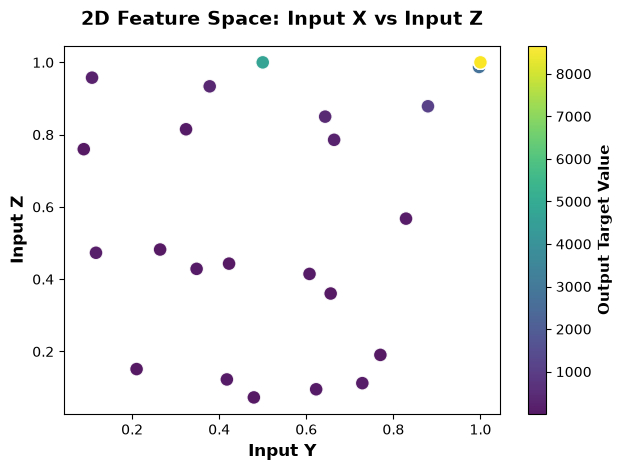

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Create scatter plot with a continuous color mapping (viridis)
scatter = plt.scatter(
    data=df, 
    x='Input_Y', 
    y='Input_Z', 
    c='Output_Target', 
    cmap='viridis', 
    s=100,            # Marker size
    edgecolor='w',    # White border around markers
    alpha=0.9
)

# Add elements
cbar = plt.colorbar(scatter)
cbar.set_label('Output Target Value', fontsize=11, fontweight='bold')
plt.xlabel('Input Y', fontsize=12, fontweight='bold')
plt.ylabel('Input Z', fontsize=12, fontweight='bold')
plt.title('2D Feature Space: Input X vs Input Z', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Train a predictive model on your 20 existing samples
predictor = RandomForestRegressor(n_estimators=100, random_state=42)
predictor.fit(inputs, output)

def objective_4d(X):
    """
    Surrogate function for 4D optimization.
    X: A 2D numpy array of shape (n_samples, 4) sent by the optimizer.
    """
    # Force input to be 2D array matrix for sklearn compatibility
    X = np.atleast_2d(X)
    
    # Predict the output value using the trained model
    predictions = predictor.predict(X)
    
    # Return as a flat 1D array as expected by your code (.ravel())
    return predictions.ravel()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

def upper_confidence_bound(mu, sigma, kappa=0.1):
    """
    Upper Confidence Bound (UCB) acquisition function.
    
    UCB = mean + kappa * std
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation
    kappa : exploration parameter (higher = more exploration)
    """
    return mu + kappa * sigma


def expected_improvement(mu, sigma, y_best, xi=0.05):
    """
    Expected Improvement (EI) acquisition function.
    
    EI = E[max(f(x) - f(x_best), 0)]
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation  
    y_best : best observed value so far
    xi : exploration parameter
    """
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

In [9]:
def bayesian_optimization_nd(objective_func, n_dims, n_iterations=5, 
                            n_initial=1, acquisition='ei'):
    """
    Bayesian Optimization for n-dimensional functions.
    Assumes bounds [0, 1] for all dimensions.
    """
    bounds = [(0, 1) for _ in range(n_dims)]
    
    # Initialize
    X_samples = inputs
    y_samples = output
    
    
    best_values = [y_samples.max()]
    
    print(f"Starting {n_dims}D optimization with {n_initial} initial samples...")
    print(f"Initial best: {y_samples.max():.4f}\n")
  
    
    for iteration in range(n_iterations):
        # Fit GP
        kernel = ConstantKernel(1.0) * Matern(length_scale=0.3,nu=1.5)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,normalize_y=True,
                                     n_restarts_optimizer=5)
        gp.fit(X_samples, y_samples)

        # Optimize acquisition function
        def acq_objective(X):
            X = X.reshape(1, -1)
            mu, sigma = gp.predict(X, return_std=True)
            
            if acquisition == 'ei':
                acq_val = expected_improvement(mu, sigma, y_samples.max())
             
            else:
                acq_val = upper_confidence_bound(mu, sigma, kappa=0.5)
            
            return -acq_val
        
        # Multi-start optimization
        best_acq = np.inf
        X_next = None


        # Build dynamic, localized acquisition optimization bounds
        # X and Y remain free (0, 1). Z is focused tightly around the 0.52 peak zone.
        localized_bounds = [
            (0.9, 1.0),  # Input_W restricted hill-climbing window
            (0.9, 1.0),  # Input_X frestricted hill-climbing window
            (0.9, 1.0),  # Input_Y free global search
            (0.9, 1.0),  # Input_Z restricted hill-climbing window
        ]

        for _ in range(50):  # More starts for higher dimensions
            # Sample initial multi-start points respecting the localized constraints
            x0 = np.array(
                [
                    np.random.uniform(localized_bounds[0][0], bounds[0][1]),
                    np.random.uniform(localized_bounds[1][0], bounds[1][1]),
                    np.random.uniform(localized_bounds[2][0], bounds[2][1]),
                    np.random.uniform(localized_bounds[3][0], bounds[3][1]),
                ])
       
            result = minimize(acq_objective, x0, bounds=localized_bounds, method='L-BFGS-B',options={"ftol": 1e-9},)
            if result.fun < best_acq:
                best_acq = result.fun
                X_next = result.x
                print(f"Optimized Next Point Found! Predicted Acquisition Score: {-best_acq:.6f}")
                print(f"Coordinates to test next: {X_next}")
            
       
        # Evaluate
        y_next = objective_func(X_next.reshape(1, -1)).ravel()
        
        # Update
        X_samples = np.vstack([X_samples, X_next])
        y_samples = np.append(y_samples, y_next)
        best_values.append(y_samples.max())
        
        if (iteration + 1) % 10 == 0:
            print(f"Iteration {iteration + 1}: Best f(x)={y_samples.max():.4f}")
    
    return X_samples, y_samples, best_values



# Run 4D optimization
X_samples_4d, y_samples_4d, best_values_4d = bayesian_optimization_nd(
    objective_4d, 
    n_dims=4,
    n_iterations=10,
    acquisition= 'ei'
)

Starting 4D optimization with 1 initial samples...
Initial best: 8662.4825

Optimized Next Point Found! Predicted Acquisition Score: 5.311746
Coordinates to test next: [1.  1.  1.  0.9]
Optimized Next Point Found! Predicted Acquisition Score: 106.171575
Coordinates to test next: [1.         1.         0.93731855 1.        ]
Optimized Next Point Found! Predicted Acquisition Score: 106.171575
Coordinates to test next: [1.         1.         0.93731855 1.        ]
Optimized Next Point Found! Predicted Acquisition Score: 106.171575
Coordinates to test next: [1.         1.         0.93731855 1.        ]
Optimized Next Point Found! Predicted Acquisition Score: 68.100756
Coordinates to test next: [1.        0.9513414 1.        1.       ]
Optimized Next Point Found! Predicted Acquisition Score: 68.100756
Coordinates to test next: [1.         0.95134139 1.         1.        ]
Optimized Next Point Found! Predicted Acquisition Score: 0.791251
Coordinates to test next: [1. 1. 1. 1.]
Optimized Next

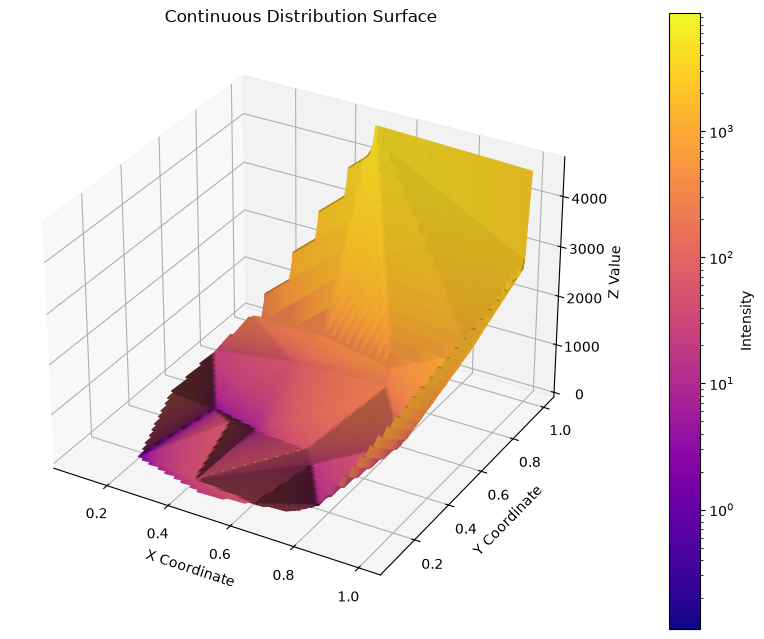

In [6]:

coords = (inputs[:,2],inputs[:,3])

# 1. Define a regular 2D grid based on your data boundaries
grid_x, grid_y = np.meshgrid(
    np.linspace(coords[0].min(), coords[0].max(), 100),
    np.linspace(coords[1].min(), coords[1].max(), 100)
)

# 2. Interpolate the scattered (x, y, z) data onto the uniform grid
# Options for method: 'linear', 'cubic', or 'nearest'
grid_z = griddata((coords[0], coords[1]), output, (grid_x, grid_y), method='linear')

# If your y_clean variable is different from values, interpolate it too for the colors
grid_color = griddata((coords[0], coords[1]), output, (grid_x, grid_y), method='linear')

# 3. Create the 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the continuous surface
# facecolors overrides standard mapping to use your output
surf = ax.plot_surface(
    grid_x, grid_y, grid_z,
    facecolors=plt.cm.plasma(colors.LogNorm(vmin=output.min(), vmax=output.max())(grid_color)),
    rcount=100, ccount=100,  # Grid resolution
    antialiased=True,
    shade=True
)

# 4. Design elements
# Create a dummy scalar mappable object just to display the colorbar correctly
mappable = plt.cm.ScalarMappable(cmap='plasma', norm=colors.LogNorm(vmin=output.min(), vmax=output.max()))
fig.colorbar(mappable, ax=ax, label="Intensity", pad=0.1)

ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_zlabel("Z Value")
ax.set_title("Continuous Distribution Surface")

plt.show()

# 3. Find where your actual candidate source is hiding
#strongest_idx = np.argmax(y_clean)
#print(f"Strongest reading value after filtering: {output[strongest_idx]}")
#print(f"Likely source location coordinate:       {coords[strongest_idx]}")